In [1]:
'''
In this example we will make a medley of FireWxPy graphics to analyze the widespread Red Flag Warning conditions
that span from the central to the southwestern U.S.

First, let's begin with our imports:
'''
# Imports the RTMA graphics module
from firewxpy import rtma
# Imports the nws_critical_firewx_forecast class from the NWS Forecasts module
from firewxpy import nws_critical_firewx_forecast as nwsfwf
# Imports the nws_relative_humidity_forecast class from the NWS Forecasts module
from firewxpy import nws_relative_humidity_forecast as nwsrh
# Imports the model_critical_firewx_conditions class from the forecast models module
from firewxpy import model_critical_firewx_conditions as fwf
# Imports the SPC module
from firewxpy import spc
# Imports the RTMA class of the data access module
from firewxpy import RTMA
# Imports our plot_creation_time() function from the standard module
from firewxpy import plot_creation_time

There is no data for 04/17/2025 17Z trying to retrieve data from the previous analysis at 04/17/2025 16Z
Data was successfully retrieved for 04/17/2025 16Z
Data was successfully retrieved for 04/16/2025 16Z
Built f:Weather Data
Built f:Weather Data/RTMA
Built f:Weather Data/RTMA/RTMA RH WITH CONTOUR THRESHOLDS
 Built f:Weather Data/RTMA/RTMA RH WITH CONTOUR THRESHOLDS/CUSTOM
Built f:Weather Data/RTMA/RTMA RH WITH CONTOUR THRESHOLDS/CUSTOM/States & Counties
Saved RTMA RH graphic to f:Weather Data/RTMA/RTMA RH WITH CONTOUR THRESHOLDS/CUSTOM/States & Counties
Built f:Weather Data/RTMA/RTMA WIND SPEED BARBS
 Built f:Weather Data/RTMA/RTMA WIND SPEED BARBS/CUSTOM
Built f:Weather Data/RTMA/RTMA WIND SPEED BARBS/CUSTOM/States & Counties
Saved RTMA Wind Speed graphic to f:Weather Data/RTMA/RTMA WIND SPEED BARBS/CUSTOM/States & Counties
Built f:Weather Data/RTMA/RTMA CRITICAL FIRE WEATHER RH 15 & WIND SPEED 15
 Built f:Weather Data/RTMA/RTMA CRITICAL FIRE WEATHER RH 15 & WIND SPEED 15/CUSTOM
Bu

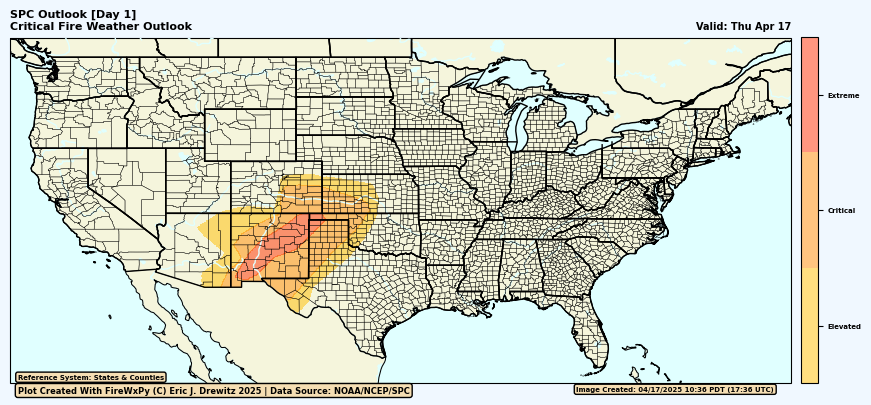

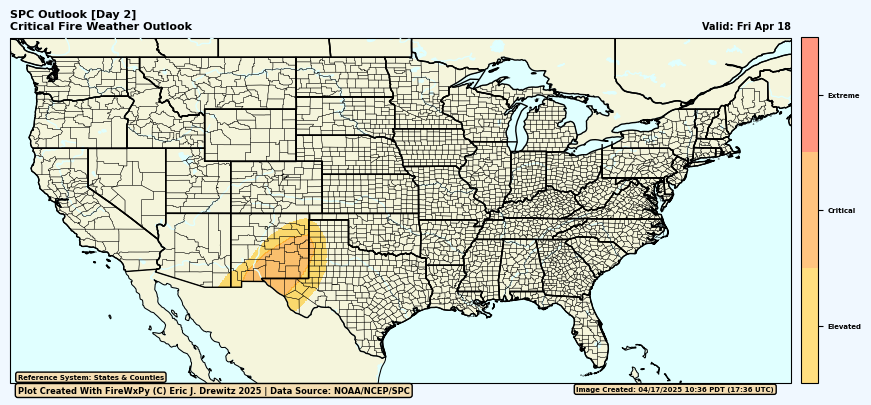

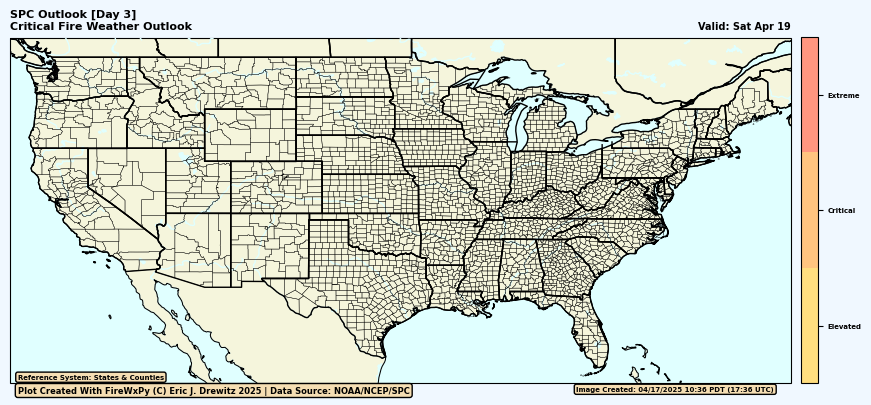

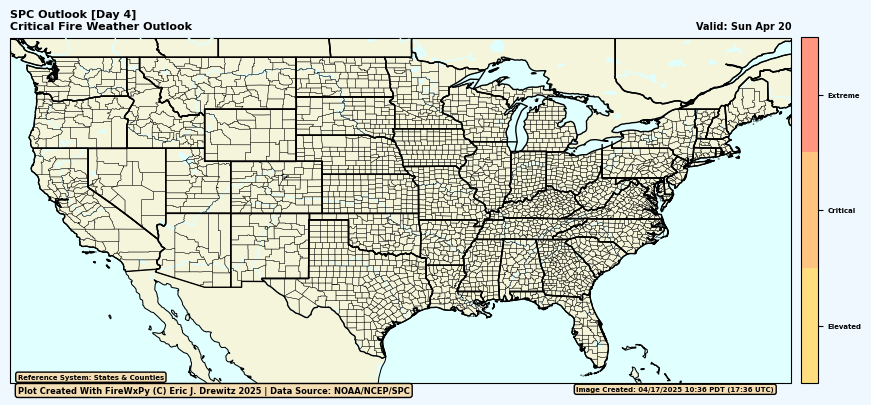

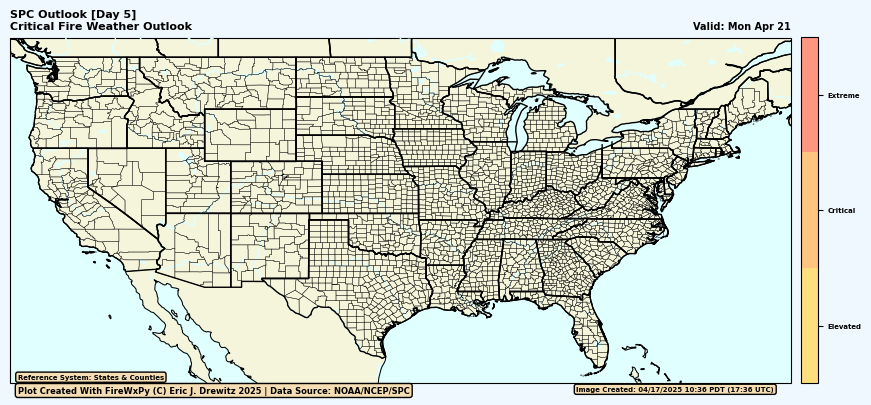

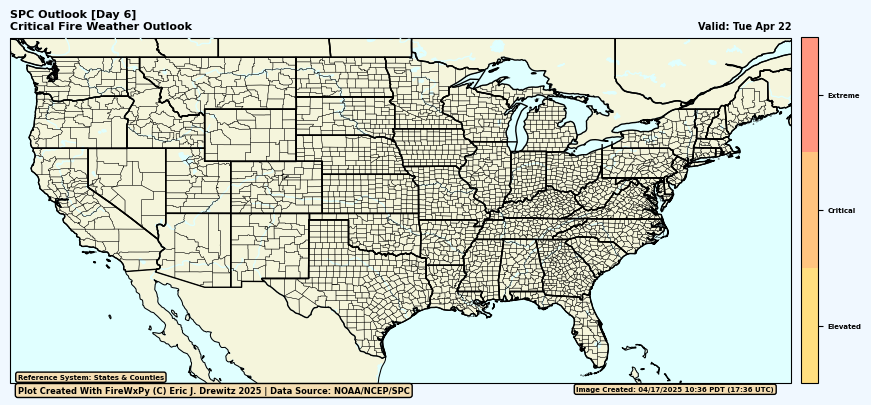

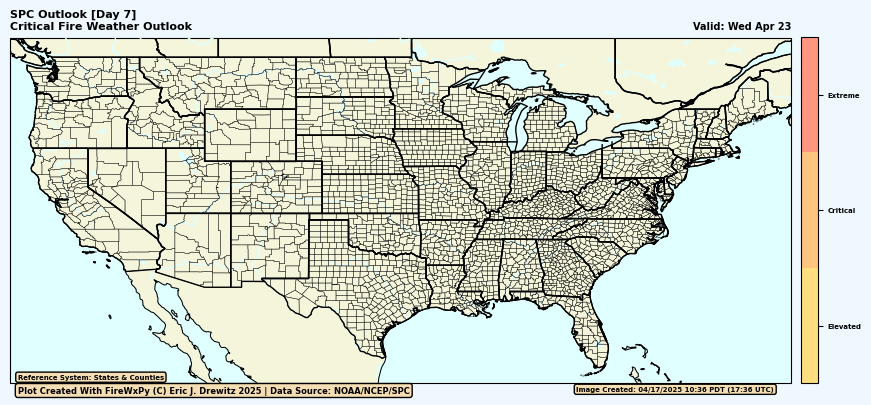

In [2]:
'''
For the RTMA data, we are using the same dataset for 3 plots so let's download the data outside of the function and 
pass the data into our RTMA plotting functions. 

All other plots use different datasets so we can save time and work by downloading the data inside of the function.
'''
# We first need our utc time to make the request for RTMA data
local_time, utc_time = plot_creation_time()

# Now let's retrieve our latest RTMA dataset
rtma_ds, rtma_24, rtma_time, rtma_time_24 = RTMA.get_rtma_datasets('conus', utc_time)

'''
Now we will make our graphics. We will pass in our rtma_ds (latest RTMA dataset) and our
rtma_time (the time of the latest RTMA dataset) into our RTMA plotting function. We also need to set data=True in our
RTMA plotting functions to flip the switch telling the function we are passing data in from the outside. 
We will also define custom boundaries to capture the inter-state area where these Red Flag Warnings span. 
We will also make any necessary adjustments to the colorbar size and anything else to ensure we have 
the best looking graphics. 

Now it is time to make our plots!
'''
rtma.plot_relative_humidity(state='custom', western_bound=-115, eastern_bound=-97, southern_bound=27, northern_bound=41.5, show_low_high_thresholds=True, data=True, ds=rtma_ds, time=rtma_time)
rtma.plot_wind_speed(state='custom', western_bound=-115, eastern_bound=-97, southern_bound=27, northern_bound=41.5, data=True, ds=rtma_ds, time=rtma_time)
rtma.plot_critical_firewx(state='custom', western_bound=-115, eastern_bound=-97, southern_bound=27, northern_bound=41.5, high_wind_threshold=15, data=True, ds=rtma_ds, time=rtma_time)
nwsfwf.plot_critical_firewx_forecast(state='custom', western_bound=-115, eastern_bound=-97, southern_bound=27, northern_bound=41.5, wind_threshold=15)
nwsrh.plot_minimum_relative_humidity_forecast(state='custom', western_bound=-115, eastern_bound=-97, southern_bound=27, northern_bound=41.5)
fwf.plot_favorable_firewx_conditions('NAM', 'custom', western_bound=-115, eastern_bound=-97, southern_bound=27, northern_bound=41.5, high_wind_threshold=15)
fwf.plot_favorable_firewx_conditions('GFS0p25', 'custom', western_bound=-115, eastern_bound=-97, southern_bound=27, northern_bound=41.5, high_wind_threshold=15)
spc.plot_critical_fire_weather_risk_outlook()